# Notebook 01 — Data Exploration
Loads all 5 datasets, computes Hopkins statistics, plots UMAP projections.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from umap import UMAP

from src.datasets import load_penguins, load_wine_data, load_digits_subset
from src.diagnostics import hopkins_statistic

os.makedirs('../outputs/figures', exist_ok=True)
CACHE_DIR = '../outputs'
os.makedirs(CACHE_DIR, exist_ok=True)

## Load datasets (built-in only for speed)

In [2]:
datasets = {
    'penguins': load_penguins(),
    'wine': load_wine_data(),
    'digits': load_digits_subset(),
}

for name, (x, y) in datasets.items():
    print(f'{name}: X={x.shape}, classes={len(np.unique(y))}')

penguins: X=(333, 4), classes=3
wine: X=(178, 13), classes=3
digits: X=(901, 64), classes=5


## Hopkins statistic — clusterability check

In [3]:
for name, (x, y) in datasets.items():
    h = hopkins_statistic(x, sample_size=50)
    print(f'{name}: Hopkins={h:.3f}  (>0.75 = strongly clustered)')

penguins: Hopkins=0.995  (>0.75 = strongly clustered)
wine: Hopkins=1.000  (>0.75 = strongly clustered)
digits: Hopkins=1.000  (>0.75 = strongly clustered)


## UMAP 2D projections (cached)

In [4]:
def get_umap_embedding(name, x):
    cache_path = f'{CACHE_DIR}/umap_{name}.pkl'
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=2)
    emb = reducer.fit_transform(x)
    joblib.dump(emb, cache_path)
    return emb

embeddings = {name: get_umap_embedding(name, x) for name, (x, y) in datasets.items()}
print('UMAP embeddings computed/loaded.')

UMAP embeddings computed/loaded.


## Plot UMAP coloured by ground truth

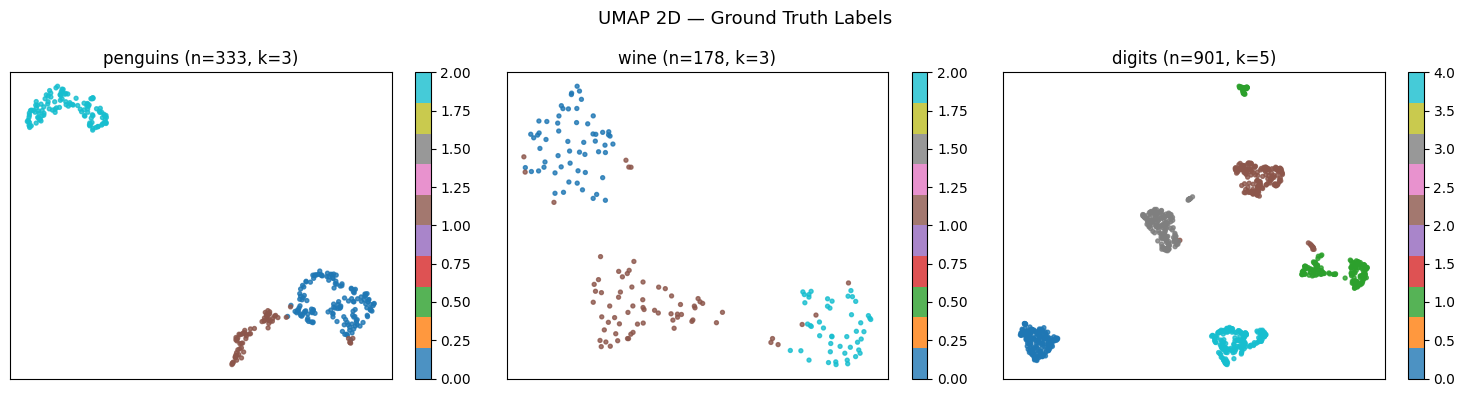

Saved 01_umap_ground_truth.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (x, y)) in zip(axes, datasets.items()):
    emb = embeddings[name]
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8, alpha=0.8)
    ax.set_title(f'{name} (n={len(y)}, k={len(np.unique(y))})')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(sc, ax=ax)
fig.suptitle('UMAP 2D — Ground Truth Labels', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/01_umap_ground_truth.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 01_umap_ground_truth.png')

## Pairwise feature distributions (penguins)

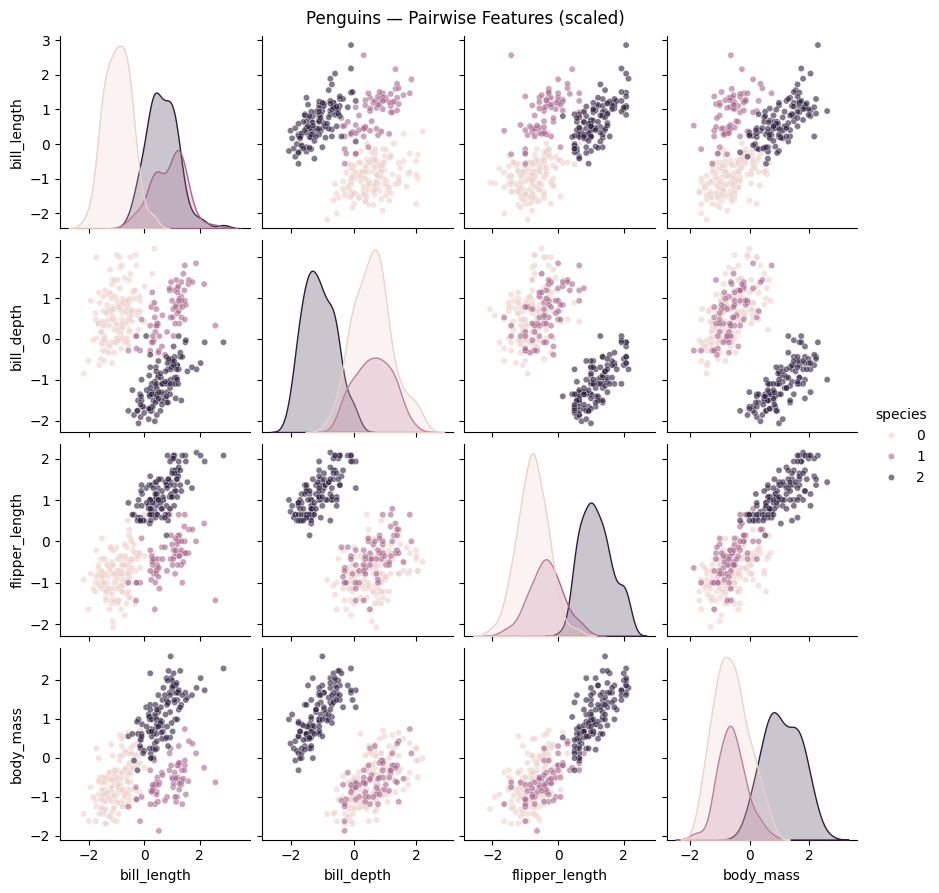

Saved 01_penguins_pairplot.png


In [6]:
import pandas as pd
x_pen, y_pen = datasets['penguins']
cols = ['bill_length', 'bill_depth', 'flipper_length', 'body_mass']
df = pd.DataFrame(x_pen, columns=cols)
df['species'] = y_pen
fig = sns.pairplot(df, hue='species', plot_kws={'alpha': 0.6, 's': 20}, height=2.2)
fig.fig.suptitle('Penguins — Pairwise Features (scaled)', y=1.01)
plt.savefig('../outputs/figures/01_penguins_pairplot.png', dpi=80, bbox_inches='tight')
plt.show()
print('Saved 01_penguins_pairplot.png')

## Summary stats

In [7]:
for name, (x, y) in datasets.items():
    print(f'\n--- {name} ---')
    print(f'  Shape: {x.shape}, Classes: {sorted(np.unique(y).tolist())}')
    print(f'  Mean: {x.mean():.4f}, Std: {x.std():.4f}')
    print(f'  Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')


--- penguins ---
  Shape: (333, 4), Classes: [0, 1, 2]
  Mean: 0.0000, Std: 1.0000
  Class distribution: {np.int64(0): np.int64(146), np.int64(1): np.int64(68), np.int64(2): np.int64(119)}

--- wine ---
  Shape: (178, 13), Classes: [0, 1, 2]
  Mean: 0.0000, Std: 1.0000
  Class distribution: {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}

--- digits ---
  Shape: (901, 64), Classes: [0, 1, 2, 3, 4]
  Mean: 0.0000, Std: 0.9763
  Class distribution: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181)}
